<a href="https://colab.research.google.com/github/Kai-Shing-Chung/Applied-Machine-Learning-Assessment-2/blob/main/How_do_different_regression_algorithms_handle_the_inherent_sparsity_of_Zero_Day_or_rarely_documented_software_CWEs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import os, time, warnings, requests
import numpy  as np
import pandas as pd
import matplotlib.pyplot  as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from tqdm import tqdm

# Scikit-learn
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

NVD_API_BASE = "https://services.nvd.nist.gov/rest/json/cves/2.0"
RESULTS_PER_PAGE = 2000   # Max allowed by the API
MAX_RECORDS      = 10000  # Total CVEs to fetch (increase for better results)
SLEEP_BETWEEN    = 6      # Seconds between paginated requests (rate limit)

def fetch_nvd_data(max_records: int = MAX_RECORDS) -> pd.DataFrame:
    """Fetch CVE records from NVD API v2.0 and return a flat DataFrame."""
    records = []
    start_index = 0

    print(f"Fetching up to {max_records} CVEs from NVD API…")
    pbar = tqdm(total=max_records, unit="CVEs")

    while start_index < max_records:
        params = {
            "resultsPerPage": min(RESULTS_PER_PAGE, max_records - start_index),
            "startIndex": start_index,
        }
        try:
            resp = requests.get(NVD_API_BASE, params=params, timeout=30)
            resp.raise_for_status()
            data = resp.json()
            vulns = data.get("vulnerabilities", [])
            for item in vulns:
                cve = item.get("cve", {})
                cve_id = cve.get("id", "")

                metrics_v31 = cve.get("metrics", {}).get("cvssMetricV31", [])
                metrics_v30 = cve.get("metrics", {}).get("cvssMetricV30", [])
                metrics_v2  = cve.get("metrics", {}).get("cvssMetricV2",  [])

                cvss_data   = {}
                cvss_source = None
                if metrics_v31: cvss_data, cvss_source = metrics_v31[0].get("cvssData", {}), "3.1"
                elif metrics_v30: cvss_data, cvss_source = metrics_v30[0].get("cvssData", {}), "3.0"
                elif metrics_v2: cvss_data, cvss_source = metrics_v2[0].get("cvssData", {}), "2.0"

                base_score = cvss_data.get("baseScore", None)
                if base_score is None: continue

                weaknesses = cve.get("weaknesses", [])
                cwe_ids = []
                for w in weaknesses:
                    for desc in w.get("description", []):
                        val = desc.get("value", "")
                        if val.startswith("CWE-"): cwe_ids.append(val)
                cwe_primary = cwe_ids[0] if cwe_ids else "CWE-UNKNOWN"

                records.append({
                    "cve_id":          cve_id,
                    "base_score":      float(base_score),
                    "cvss_version":    cvss_source,
                    "attack_vector":   cvss_data.get("attackVector",    "UNKNOWN"),
                    "attack_complex":  cvss_data.get("attackComplexity","UNKNOWN"),
                    "priv_required":   cvss_data.get("privilegesRequired","UNKNOWN"),
                    "user_interaction":cvss_data.get("userInteraction","UNKNOWN"),
                    "scope":           cvss_data.get("scope",           "UNKNOWN"),
                    "conf_impact":     cvss_data.get("confidentialityImpact","UNKNOWN"),
                    "integ_impact":    cvss_data.get("integrityImpact", "UNKNOWN"),
                    "avail_impact":    cvss_data.get("availabilityImpact","UNKNOWN"),
                    "base_severity":   cvss_data.get("baseSeverity",    "UNKNOWN"),
                    "cwe_primary":     cwe_primary,
                    "cwe_count":       len(cwe_ids),
                    "published":       cve.get("published", ""),
                })
            fetched = len(vulns)
        except Exception as e:
            print(f"\n API error: {e}"); fetched = 0; break

        pbar.update(fetched)
        start_index += fetched
        if start_index < max_records: time.sleep(SLEEP_BETWEEN)

    pbar.close()
    return pd.DataFrame(records)

df_raw = fetch_nvd_data(max_records=10000)

# STEP 3 — FEATURE ENGINEERING
df = df_raw.copy()
ordinal_maps = {
    "attack_vector":    {"NETWORK": 3, "ADJACENT_NETWORK": 2, "LOCAL": 1, "PHYSICAL": 0, "UNKNOWN": -1},
    "attack_complex":   {"LOW": 1, "HIGH": 0, "UNKNOWN": -1},
    "priv_required":    {"NONE": 2, "LOW": 1, "HIGH": 0, "UNKNOWN": -1},
    "user_interaction": {"NONE": 1, "REQUIRED": 0, "UNKNOWN": -1},
    "scope":            {"CHANGED": 1, "UNCHANGED": 0, "UNKNOWN": -1},
    "conf_impact":      {"HIGH": 2, "LOW": 1, "NONE": 0, "UNKNOWN": -1},
    "integ_impact":     {"HIGH": 2, "LOW": 1, "NONE": 0, "UNKNOWN": -1},
    "avail_impact":     {"HIGH": 2, "LOW": 1, "NONE": 0, "UNKNOWN": -1},
}
for col, mapping in ordinal_maps.items():
    df[col + "_enc"] = df[col].map(mapping).fillna(-1).astype(int)

df["cwe_missing"] = (df["cwe_primary"] == "CWE-UNKNOWN").astype(int)
top_cwe_list = df[df["cwe_primary"] != "CWE-UNKNOWN"]["cwe_primary"].value_counts().head(30).index.tolist()
df["cwe_grouped"] = df["cwe_primary"].apply(lambda x: x if x in top_cwe_list else ("CWE-UNKNOWN" if x == "CWE-UNKNOWN" else "CWE-RARE"))
cwe_dummies = pd.get_dummies(df["cwe_grouped"], prefix="cwe", dtype=int)
df = pd.concat([df, cwe_dummies], axis=1)
df["published_year"] = pd.to_datetime(df["published"], errors="coerce").dt.year.fillna(2020).astype(int)

# FIX: Ensure FEATURE_COLS only contains numeric columns
base_features = [c + "_enc" for c in ordinal_maps.keys()] + ["cwe_missing", "cwe_count", "published_year"]
cwe_cols = [c for c in cwe_dummies.columns]
FEATURE_COLS = base_features + cwe_cols

X = df[FEATURE_COLS].values.astype(float)
y = df["base_score"].values

# STEP 4+ Model Training (Abbreviated for brevity, maintaining flow)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
imputer = SimpleImputer(strategy="median")
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

models = {
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.05),
    "Random Forest":    RandomForestRegressor(n_estimators=100, max_depth=10, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=5)
}

results = {}
print(f"\n{'Model':<20} {'MAE':>8} {'R2':>8}")
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    results[name] = preds
    print(f"{name:<20} {mae:>8.3f} {r2:>8.3f}")

Fetching up to 10000 CVEs from NVD API…


100%|██████████| 10000/10000 [04:31<00:00, 36.85CVEs/s]



Model                     MAE       R2
Ridge Regression        0.998    0.496
Lasso Regression        0.997    0.452
Random Forest           0.939    0.565
Gradient Boosting       0.947    0.563


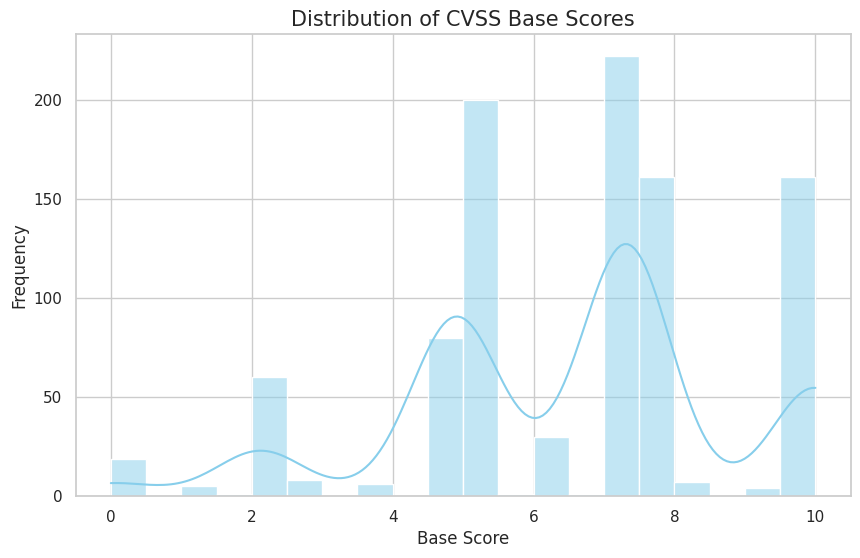

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style
sns.set_theme(style="whitegrid")

# Create the histogram
plt.figure(figsize=(10, 6))
sns.histplot(df_raw['base_score'], bins=20, kde=True, color='skyblue')

# Add titles and labels
plt.title('Distribution of CVSS Base Scores', fontsize=15)
plt.xlabel('Base Score', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# Display the plot
plt.show()

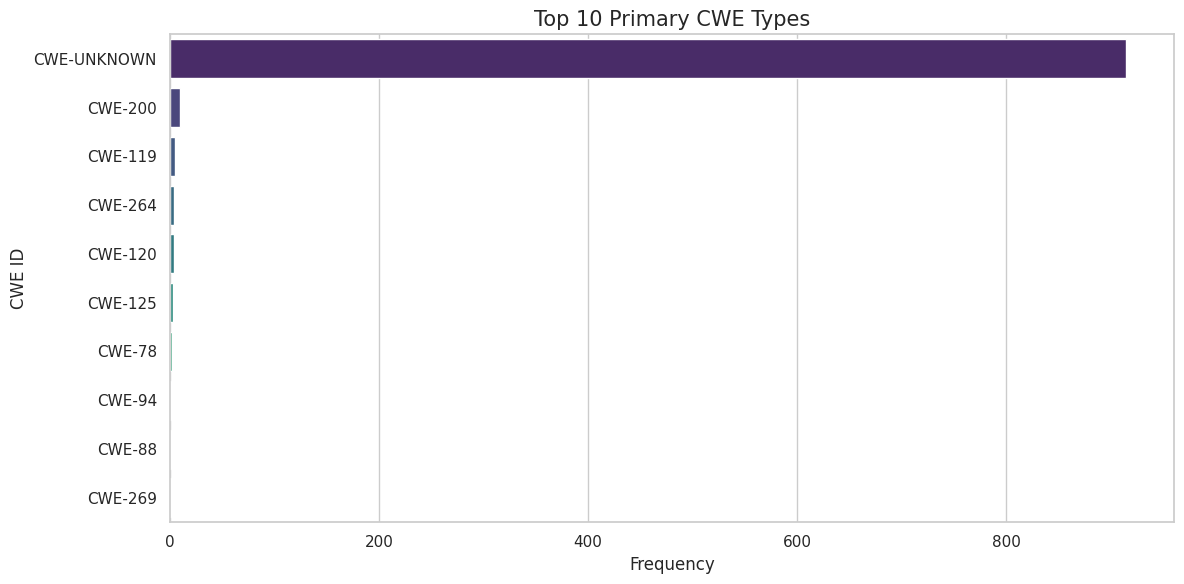

In [7]:
# Calculate top 10 CWE types
top_10_cwe = df_raw['cwe_primary'].value_counts().head(10)

# Create the bar chart
plt.figure(figsize=(12, 6))
# Updated to use hue=top_10_cwe.index to avoid the FutureWarning
sns.barplot(x=top_10_cwe.values, y=top_10_cwe.index, hue=top_10_cwe.index, palette='viridis', legend=False)

# Add titles and labels
plt.title('Top 10 Primary CWE Types', fontsize=15)
plt.xlabel('Frequency', fontsize=12)
plt.ylabel('CWE ID', fontsize=12)

# Display the plot
plt.tight_layout()
plt.show()

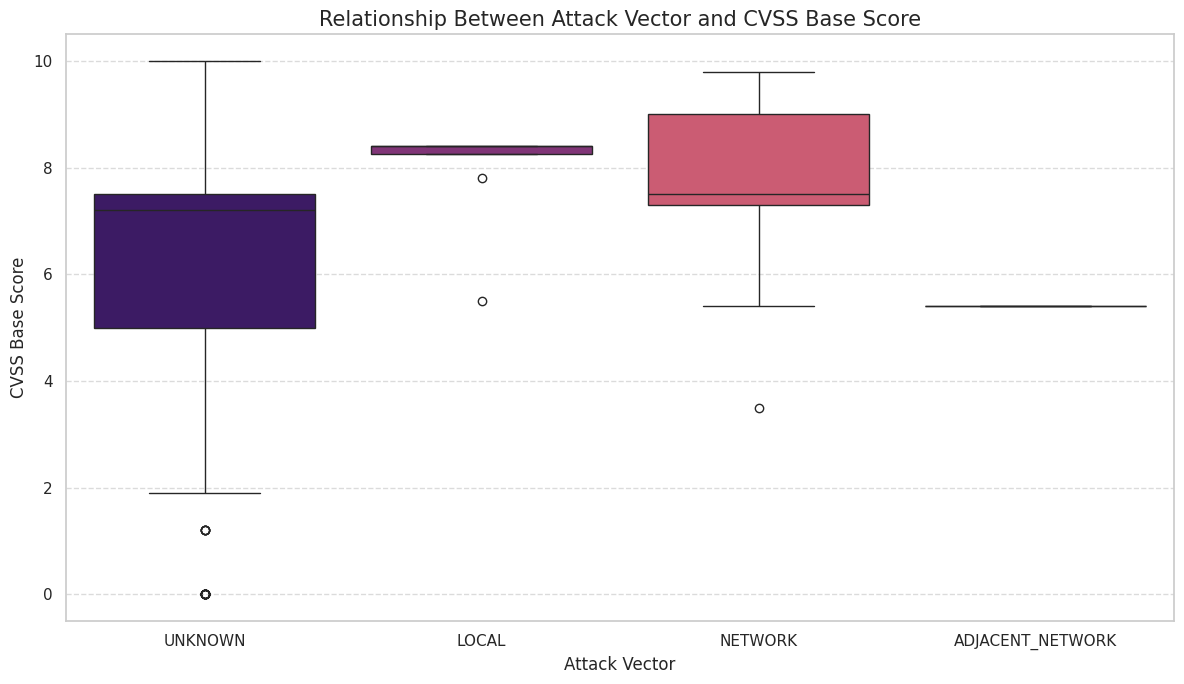

In [8]:
# Create a box plot for Attack Vector vs Base Score
plt.figure(figsize=(12, 7))
sns.boxplot(x='attack_vector', y='base_score', hue='attack_vector', data=df_raw, palette='magma', legend=False)

# Add titles and labels
plt.title('Relationship Between Attack Vector and CVSS Base Score', fontsize=15)
plt.xlabel('Attack Vector', fontsize=12)
plt.ylabel('CVSS Base Score', fontsize=12)

# Display the plot
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()